# Contrastive Learning — Light Curve Data Visualization (New Dataset)

This notebook visualizes the **new multi-band light curve dataset** (`light_curves.csv`) and prepares plots that are compatible with the available columns (e.g., `oid`, `mjd`, `fid`, `magpsf`, `sigmapsf`, `ra`, `dec`).


<details>
<summary>📌 Cell Description: Importing Libraries and Loading the Standardized Dataset for Visualization</summary>

This cell prepares the environment for dimensionality-reduction visualizations by importing the required Python libraries and loading the previously standardized dataset. Since visualization methods like PCA, t-SNE, and UMAP require clean numerical inputs, this step ensures the dataset is properly loaded before applying these advanced techniques. The cell imports core data analysis tools (Pandas, NumPy), visualization libraries (Matplotlib, Seaborn), and dimensionality-reduction methods (PCA, t-SNE, and optionally UMAP). It also checks whether the UMAP package is installed and sets a flag accordingly.

The standardized dataset—created in the earlier preprocessing step—is loaded from disk. Standardized data is ideal for dimensionality-reduction algorithms because all numerical features share a common scale, preventing distortions in visual representations. The cell prints the dataset’s shape and shows the first few rows, allowing the researcher to verify that the correct dataset has been loaded successfully.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Imports essential analysis and visualization libraries**, preparing the environment for plotting and dimensionality reduction.  
- **Loads PCA, t-SNE, and optionally UMAP**, which are powerful techniques for visualizing high-dimensional data in 2D or 3D.  
- **Configures Seaborn styling** to create clean and visually appealing plots.  
- **Loads the standardized dataset from disk**, ensuring that all numerical features are already scaled and ready for modeling.  
- **Includes a safety check** to confirm that the standardized file exists, preventing errors later on.  
- **Prints the dataset shape** so the researcher knows how many rows and columns have been loaded.  
- **Displays the first few rows**, offering a quick sanity check on whether the correct data has been loaded.  
- **Prepares the foundation for visualization techniques**, such as clustering patterns or separating astronomical observations in reduced-dimensional space.

---

### ⭐ **Why This Cell Is Important for the Research**
Dimensionality reduction is a key step for understanding large astronomical datasets, which often contain many numerical features. Methods such as PCA, t-SNE, and UMAP help reveal hidden patterns, clusters, or separations between different types of astronomical objects. These insights can guide model development, anomaly detection, or scientific interpretation. By loading the standardized dataset and importing the necessary tools, this cell ensures that the upcoming visualizations are accurate, stable, and scientifically meaningful.

</details>


In [2]:
#pip install matplotlib

In [3]:
# Imports + load dataset (light_curves.csv)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional (may not be installed in all environments)
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

sns.set_context("notebook")

# ---------------------------
# Load the new dataset
# ---------------------------
DEFAULT_PATHS = [
    "/mnt/data/light_curves.csv",   # sandbox path
    "light_curves.csv",             # local run
]

data_path = next((p for p in DEFAULT_PATHS if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError("Could not find light_curves.csv. Place it next to this notebook or under /mnt/data/")

df = pd.read_csv(data_path)
print("Loaded:", data_path)
print("Shape:", df.shape)
display(df.head())

# ---------------------------
# Standardize column choices for plotting
# ---------------------------
# Prefer PSF magnitude if available (common in ZTF), else fall back to 'mag'
if "magpsf" in df.columns:
    df["mag_used"] = pd.to_numeric(df["magpsf"], errors="coerce")
elif "mag" in df.columns:
    df["mag_used"] = pd.to_numeric(df["mag"], errors="coerce")
else:
    df["mag_used"] = np.nan

# Prefer PSF magnitude uncertainty if available, else fall back to 'e_mag'
if "sigmapsf" in df.columns:
    df["err_used"] = pd.to_numeric(df["sigmapsf"], errors="coerce")
elif "e_mag" in df.columns:
    df["err_used"] = pd.to_numeric(df["e_mag"], errors="coerce")
else:
    df["err_used"] = np.nan

# Map ZTF filter IDs (fid) to names when possible
if "fid" in df.columns:
    fid_map = {1: "g", 2: "r", 3: "i"}
    df["filter_name"] = pd.to_numeric(df["fid"], errors="coerce").map(fid_map).fillna(df["fid"].astype(str))
else:
    df["filter_name"] = "unknown"

# ---------------------------
# Dataset-aligned "observation quality" proxy (no extra metadata required)
# ---------------------------
# If error is high -> observation quality is likely worse
if df["err_used"].notna().any():
    e = df["err_used"].copy()
    e_med = float(e.median())
    e_std = float(e.std()) if float(e.std()) > 0 else 1.0
    df["obs_quality_index"] = (e.fillna(e_med) - e_med) / e_std
else:
    df["obs_quality_index"] = np.nan

print("Added helper columns:", [c for c in ["mag_used","err_used","filter_name","obs_quality_index"] if c in df.columns])



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\ProgramData\anaconda3\Lib\site-pack

...


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\ProgramData\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

<details>
<summary>📌 Cell Description: Generating Summary Statistics and Checking Dataset Completeness</summary>

This cell provides an initial statistical overview of the standardized dataset. Before running dimensionality-reduction or visualization techniques, it is essential to understand the dataset’s structure, completeness, and basic statistical properties. This cell prints the number of columns, shows the distribution of data types, identifies missing values, and displays descriptive statistics for all numerical features. These quick checks help verify that the dataset is clean, consistent, and ready for deeper analysis.

By summarizing the dataset in this way, the researcher can confirm whether scaling worked correctly, whether all numerical features fall within reasonable ranges, and whether any unexpected missing values or anomalies remain. These insights are crucial for validating data quality before applying machine-learning or scientific visualization methods.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Counts and displays the number of columns**, giving a quick overview of dataset width.  
- **Shows the distribution of data types** (e.g., floats, integers), helping verify that the dataset is correctly structured for analysis.  
- **Identifies missing values per column**, sorted from highest to lowest, to easily spot potential problems.  
- **Prints descriptive statistics** for all numerical features, including:  
  - mean  
  - standard deviation  
  - minimum and maximum values  
  - quartiles  
  These statistics help assess whether numerical values lie within reasonable scientific ranges.  
- **Highlights potential anomalies**, such as unexpected large values or sudden variance changes.  
- **Confirms data readiness** for visualizations like PCA, t-SNE, and UMAP.  
- **Reassures that the cleaned and standardized dataset is behaving as expected**, with no hidden issues.

---

### ⭐ **Why This Cell Is Important for the Research**
Summary statistics serve as a final validation checkpoint before deeper exploration. In astronomy, numerical features may vary greatly in magnitude, so reviewing their distributions helps detect any remaining inconsistencies or errors from earlier preprocessing steps. Clean and well-understood data leads to more trustworthy visualizations, machine-learning models, and scientific conclusions. This cell ensures that the standardized dataset is stable, complete, and ready for high-level analysis.

</details>


In [ ]:
# Quick summary statistics and missingness
print('Columns:', df.shape[1])
print('Data types:')
print(df.dtypes.value_counts())
print('Missing per column:')
print(df.isnull().sum().sort_values(ascending=False).head(20))
print('Numeric describe:')
display(df.select_dtypes(include=['number']).describe().T)


Columns: 14
Data types:
float64    10
object      2
int64       2
Name: count, dtype: int64
Missing per column:
mag                  20000
e_mag                20000
oid                      0
mjd                      0
fid                      0
magpsf                   0
sigmapsf                 0
ra                       0
dec                      0
isdiffpos                0
mag_used                 0
err_used                 0
filter_name              0
obs_quality_index        0
dtype: int64
Numeric describe:


,count,mean,std,min,25%,50%,75%,max
mjd,20000.0,59743.034598,751.635994,58252.436134,59070.339144,5.970835e+04,60481.364436,61038.162083
fid,20000.0,1.473900,0.499331,1.000000,1.000000,1.000000e+00,2.000000,2.000000
mag,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e_mag,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
magpsf,20000.0,16.593490,1.177505,13.544434,15.501700,1.655420e+01,17.567647,20.537700
sigmapsf,20000.0,0.082575,0.045597,0.009013,0.055472,7.719500e-02,0.103613,0.499309
ra,20000.0,308.026667,17.541764,274.381715,307.792422,3.197259e+02,319.726062,319.726905
dec,20000.0,56.866286,3.004132,51.134366,58.422322,5.842242e+01,58.422493,58.493867
isdiffpos,20000.0,0.560200,0.828378,-1.000000,1.000000,1.000000e+00,1.000000,1.000000
mag_used,20000.0,16.593490,1.177505,13.544434,15.501700,1.655420e+01,17.567647,20.537700


<details>
<summary>📌 Cell Description: Univariate Analysis Using Histograms and KDE Plots</summary>

This cell performs **univariate analysis**, which means examining each numerical feature individually to understand its basic distribution. The cell selects all numerical columns, samples up to 20,000 rows for efficiency (if the dataset is very large), and then plots histograms with KDE (Kernel Density Estimation) curves for the first 12 numerical features. These plots reveal how each feature is spread—whether values cluster in certain ranges, whether the distribution is skewed, or whether unusual patterns appear.

Histograms and KDEs are simple yet powerful tools to visually inspect whether the cleaned and standardized dataset behaves normally. This helps confirm that earlier preprocessing steps, such as scaling, outlier removal, and feature engineering, were successful. The visual patterns from these plots also provide insight into the astrophysical properties represented in the dataset, such as brightness measurements, positional values, or signal-related quantities.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Selects all numerical columns** for visualization, focusing only on measurable features.  
- **Uses sampling (up to 20,000 rows)** to keep plotting efficient and avoid slow rendering for very large datasets.  
- **Plots histograms + KDE curves** to show how each feature is distributed.  
- **Limits plots to the first 12 columns** for readability, but this can be adjusted anytime.  
- **Helps identify distribution shapes** such as:  
  - normal (bell-shaped)  
  - skewed  
  - wide or narrow spread  
  - multi-modal (multiple peaks)  
- **Visually checks for anomalies**, such as unexpected spikes or remaining outliers.  
- **Confirms the effectiveness of earlier preprocessing** (e.g., scaling and log transforms).  
- **Supports scientific interpretation**, because the shape of each distribution can reflect real astronomical behaviors or instrument characteristics.

---

### ⭐ **Why This Cell Is Important for the Research**
Understanding the individual distribution of each numerical feature is a foundation of data exploration. In astronomy, different measurements can have very different numerical scales and shapes. Histograms and KDEs help reveal whether features are well-behaved, whether additional transformations are needed, and whether any data quality issues remain. This visualization step ensures the dataset is ready for high-level analysis, such as dimensionality reduction, clustering, or machine-learning modelling.

</details>


Numeric columns count: 12


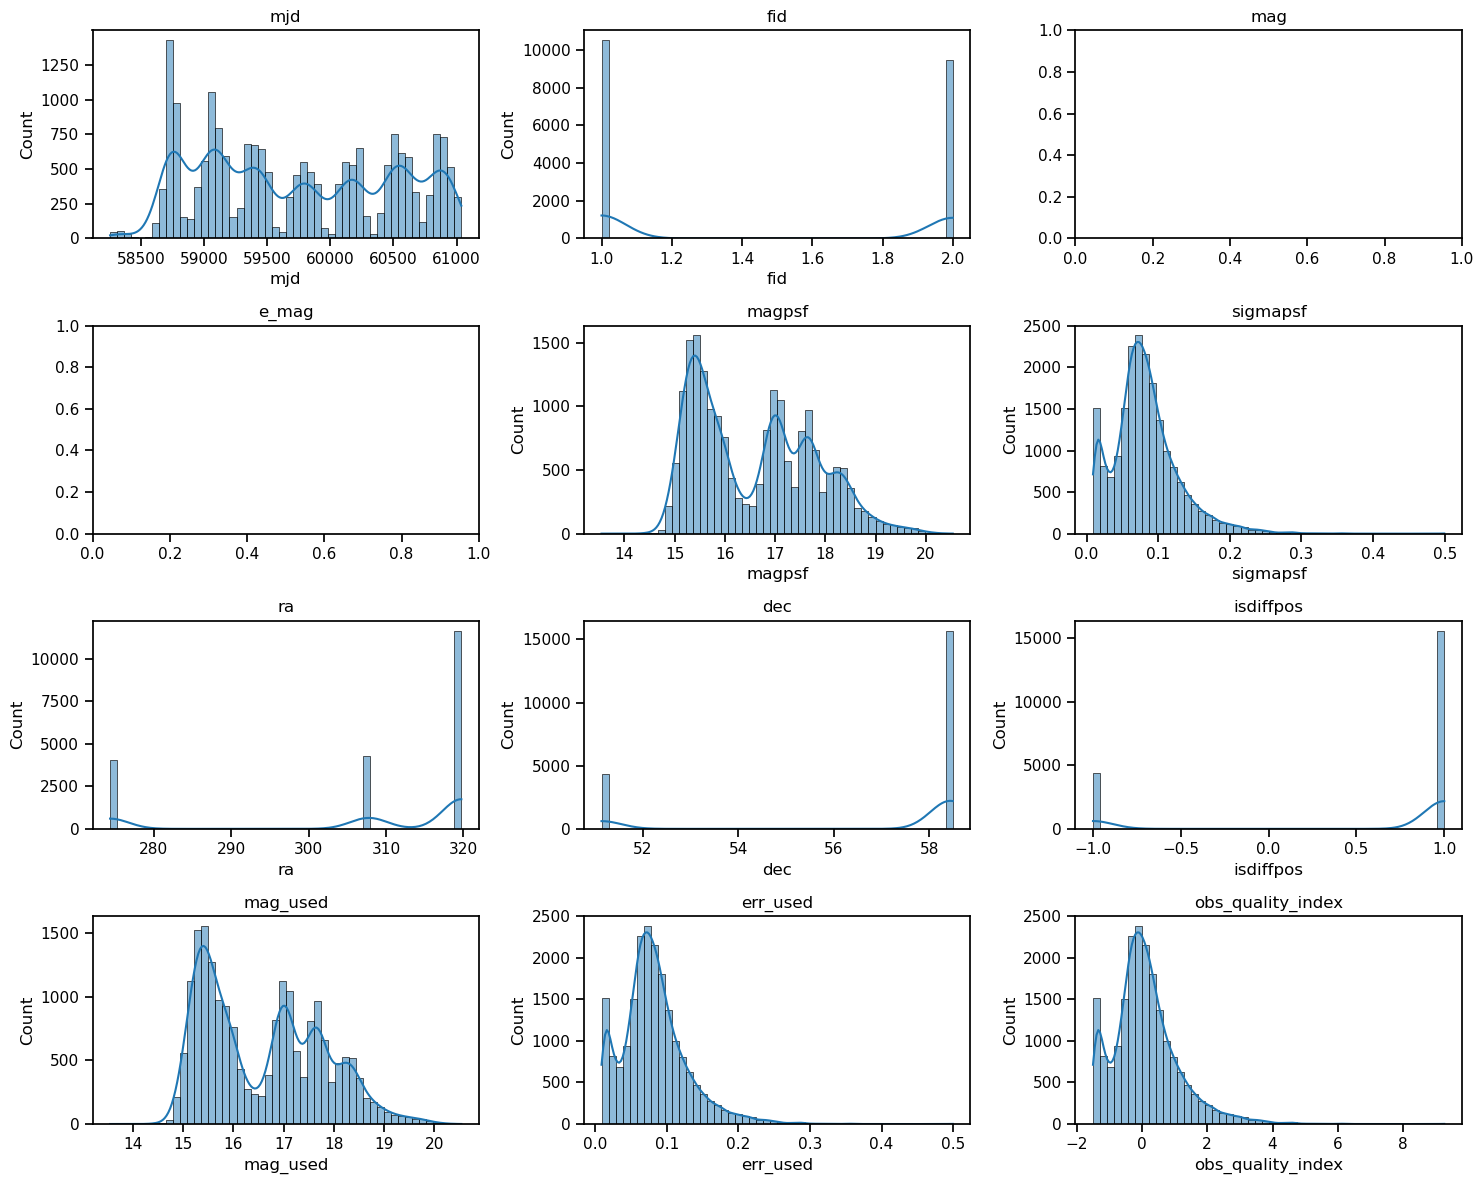

In [ ]:
# Univariate: Histograms + KDEs for numeric columns (sampled if too many rows)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print('Numeric columns count:', len(num_cols))
sample = df.sample(n=20000, random_state=42) if df.shape[0] > 20000 else df
cols_to_plot = num_cols[:12]  # limit to first 12 for brevity; change as needed
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15,12))
axes = axes.flatten()
for i, c in enumerate(cols_to_plot):
    sns.histplot(sample[c].dropna(), kde=True, ax=axes[i], bins=50, color='C0')
    axes[i].set_title(c)
plt.tight_layout()
plt.show()

<details>
<summary>📌 Cell Description: Univariate Boxplots to Visualize Outliers in Numerical Features</summary>

This cell creates **boxplots** for the same numerical columns used in the histogram analysis. While histograms show the overall distribution of each feature, boxplots are specifically designed to highlight **outliers**, **spread**, and **central tendency** in a clean and compact way. By plotting boxplots for the selected numerical features, the cell allows the researcher to visually inspect whether any extreme values remain after the earlier outlier-removal and preprocessing steps.

The boxplots help confirm whether the cleaned dataset is well-behaved, whether skewed distributions still exist, and whether certain features naturally have a wider variability due to astrophysical reasons. This step serves as a visual validation of the quality of the dataset before performing more advanced methods like PCA, t-SNE, or clustering.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Uses boxplots**, which are powerful tools for detecting leftover outliers and understanding data spread.  
- **Plots the same columns as histograms** to give a consistent view of each feature’s behavior.  
- **Uses a sampled dataset** to keep the visualization efficient and readable.  
- **Shows key components of a distribution**:  
  - median (middle value)  
  - interquartile range (IQR)  
  - whiskers (spread of typical values)  
  - individual outlier points  
- **Reveals whether preprocessing successfully removed extreme values**, or if additional cleaning is needed.  
- **Helps identify skewness**, long tails, or unusual patterns in astronomical measurements.  
- **Provides a compact summary**, ideal for comparing many features at once.  
- **Supports scientific interpretation**, since certain astrophysical measurements naturally show wide variability or skewness.

---

### ⭐ **Why This Cell Is Important for the Research**
Outliers can distort machine-learning models and give misleading scientific conclusions. Boxplots provide a fast and intuitive way to confirm that earlier cleaning steps—such as IQR-based filtering and log transformations—have worked correctly. They allow the researcher to visually ensure that only meaningful, physically realistic values remain in the dataset. This verification step is crucial before applying dimensionality reduction or building ML models, especially in astronomy, where measurement noise and extreme values are common.

</details>


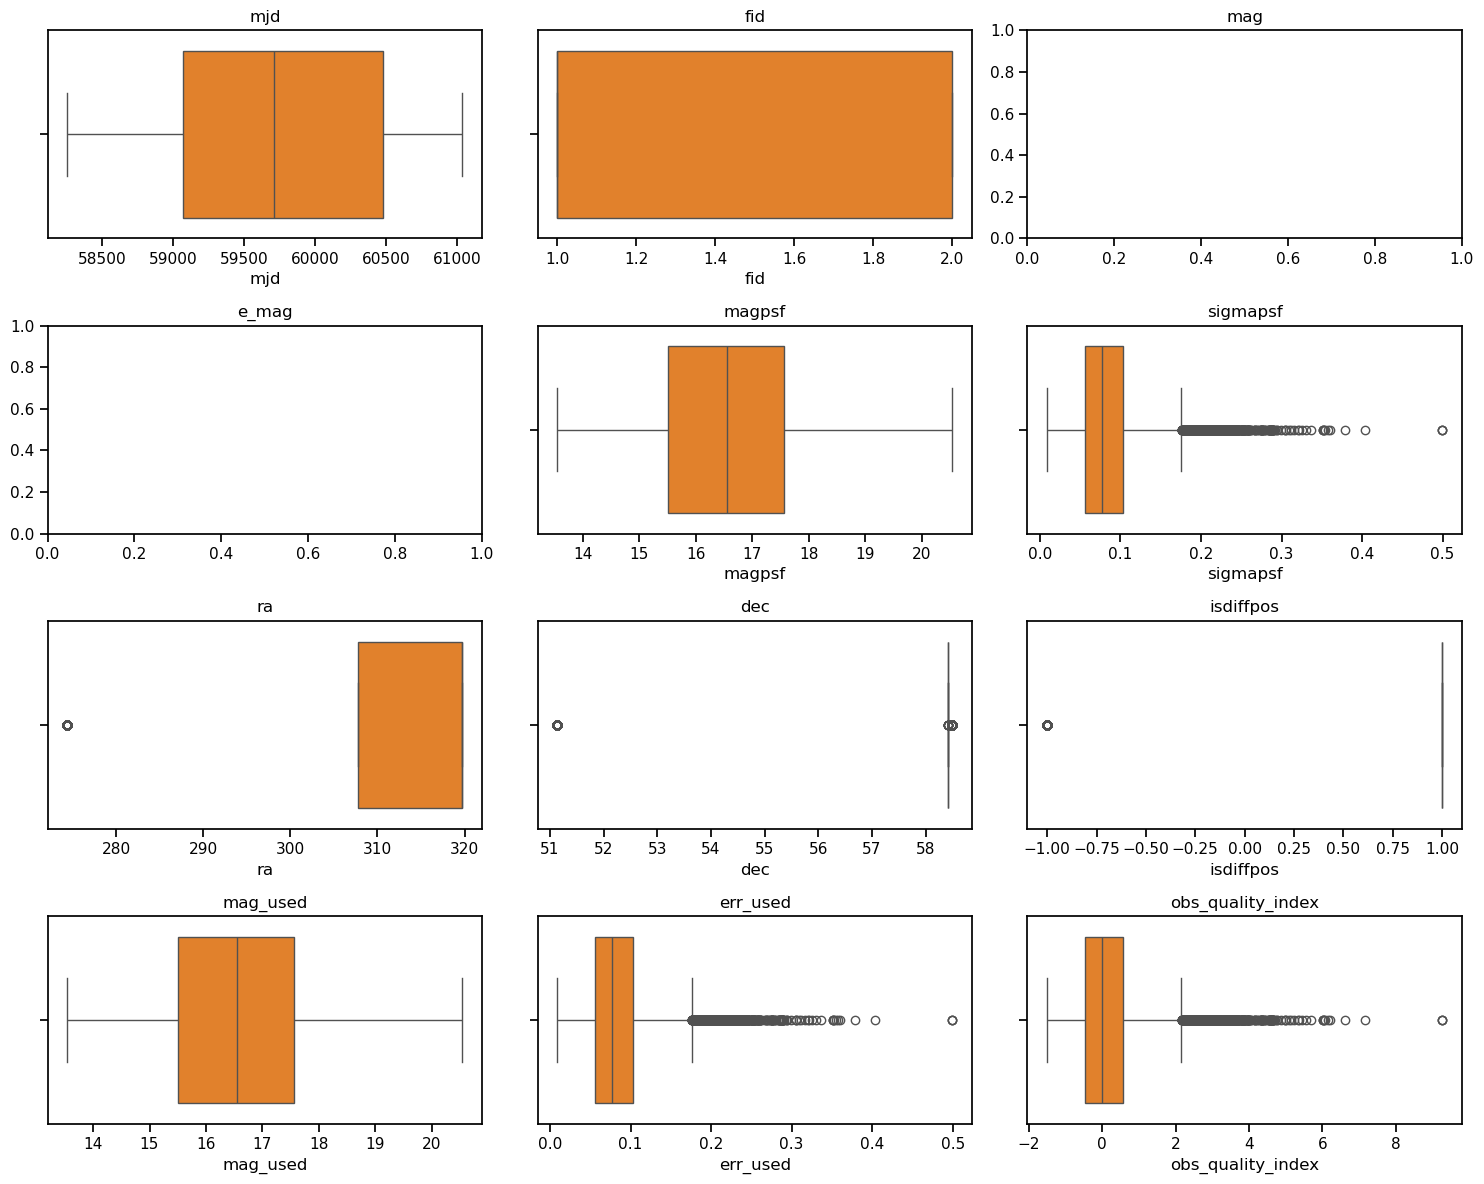

In [ ]:
# Univariate: Boxplots to highlight outliers for the same numeric columns
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15,12))
axes = axes.flatten()
for i, c in enumerate(cols_to_plot):
    sns.boxplot(x=sample[c].dropna(), ax=axes[i], color='C1')
    axes[i].set_title(c)
plt.tight_layout()
plt.show()

<details>
<summary>📌 Cell Description: Exploring Categorical Features Using Value Counts and Bar Plots</summary>

This cell analyzes all categorical (non-numeric) columns in the dataset by counting how many times each category appears and visualizing the top 20 categories with bar plots. In astronomical metadata, categorical fields may include filter names, file types, detector IDs, processing flags, or observation modes. Understanding the distribution of these categories is important because it reveals how the dataset is structured and whether certain categories dominate the observations.

The bar plots help identify patterns such as frequently used filters, common observation conditions, or dominant detector configurations. This information is valuable for evaluating dataset balance, potential biases, and understanding which categories might influence later modelling steps. If any category appears extremely rarely or overwhelmingly often, it can guide preprocessing decisions or feature selection strategies.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Identifies all categorical columns** (text-based or label-based fields).  
- **Counts the frequency of each category**, showing how often each type appears in the dataset.  
- **Displays only the top 20 categories** to keep the charts readable and focused.  
- **Generates bar plots** for each categorical feature using Seaborn’s clean styling.  
- **Helps detect imbalance**, such as when one category heavily dominates others.  
- **Supports understanding of dataset composition**, especially in astronomy where different filters or instruments may contribute differently.  
- **Useful for feature engineering**, such as deciding whether a categorical field should be encoded, grouped, or simplified.  
- **Visualizes metadata distribution**, providing a quick overview of observational conditions or file-related properties.

---

### ⭐ **Why This Cell Is Important for the Research**
Categorical variables can significantly influence scientific interpretation and machine-learning performance. For example, if most observations were recorded using a single filter or instrument, this could bias the model or limit generalization. Visualizing category distributions helps the researcher understand dataset structure, identify potential sampling biases, and make informed decisions about encoding or balancing categorical fields. This step ensures that non-numerical metadata is examined with the same rigor as numerical features, leading to a comprehensive understanding of the dataset before modelling.

</details>


Categorical columns: ['oid', 'filter_name']


C:\Users\NIPUN\AppData\Local\Temp\ipykernel_19848\184079033.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


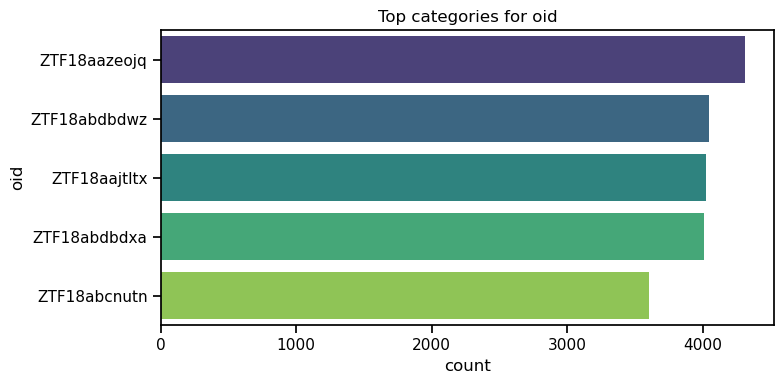

C:\Users\NIPUN\AppData\Local\Temp\ipykernel_19848\184079033.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='viridis')


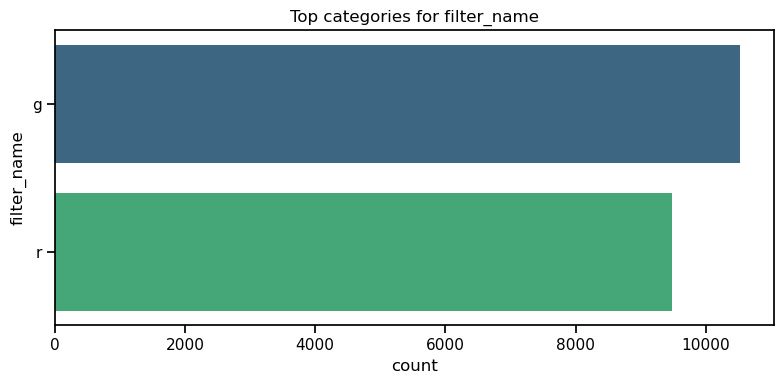

In [ ]:
# Categorical / object columns: value counts and bar plots for top categories
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)
for c in cat_cols:
    vc = df[c].value_counts().nlargest(20)
    plt.figure(figsize=(8,4))
    sns.barplot(x=vc.values, y=vc.index, palette='viridis')
    plt.title(f'Top categories for {c}')
    plt.xlabel('count')
    plt.tight_layout()
    plt.show()

<details>
<summary>📌 Cell Description: Correlation Heatmap for Understanding Relationships Between Numerical Features</summary>

This cell computes and visualizes a **correlation matrix** for all numerical features in the dataset. Correlation measures how strongly two variables move together—either in the same direction (positive correlation) or in opposite directions (negative correlation). By plotting these relationships in a heatmap, the researcher can easily identify which numerical features are closely related, which ones behave independently, and whether any groups of features cluster together.

The heatmap uses an upper-triangle mask to avoid repeating the same information twice, making the plot cleaner and easier to read. Understanding feature correlations is essential before applying dimensionality reduction or machine-learning models, because highly correlated features can provide redundant information, while uncorrelated ones may capture unique aspects of the astronomical data.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Calculates the correlation matrix** for all numerical columns in the dataset.  
- **Visualizes correlations using a heatmap**, allowing easy interpretation of relationships.  
- **Uses a triangular mask** to display only half of the matrix, keeping the plot uncluttered.  
- **Shows positive correlations** (features increasing together).  
- **Shows negative correlations** (one feature increases while the other decreases).  
- **Highlights independent features**, which have correlations near zero.  
- **Helps identify redundant features**, which may be removed or compressed in future steps.  
- **Supports PCA and other dimensionality-reduction methods**, since correlation structure influences how features cluster in lower-dimensional space.  
- **Provides scientific insight**, as certain astronomical measurements naturally correlate due to telescope physics or observational conditions.

---

### ⭐ **Why This Cell Is Important for the Research**
Understanding how numerical features relate to each other is a fundamental part of exploratory data analysis. In astronomy, correlations may arise due to detector behavior, filter selection, sky conditions, or physical relationships in the observed objects. Identifying these patterns helps the researcher understand the underlying structure of the dataset, reduces redundancy, and guides feature selection for machine-learning tasks. This heatmap ensures that the dataset is scientifically interpretable and ready for advanced modelling techniques.

</details>


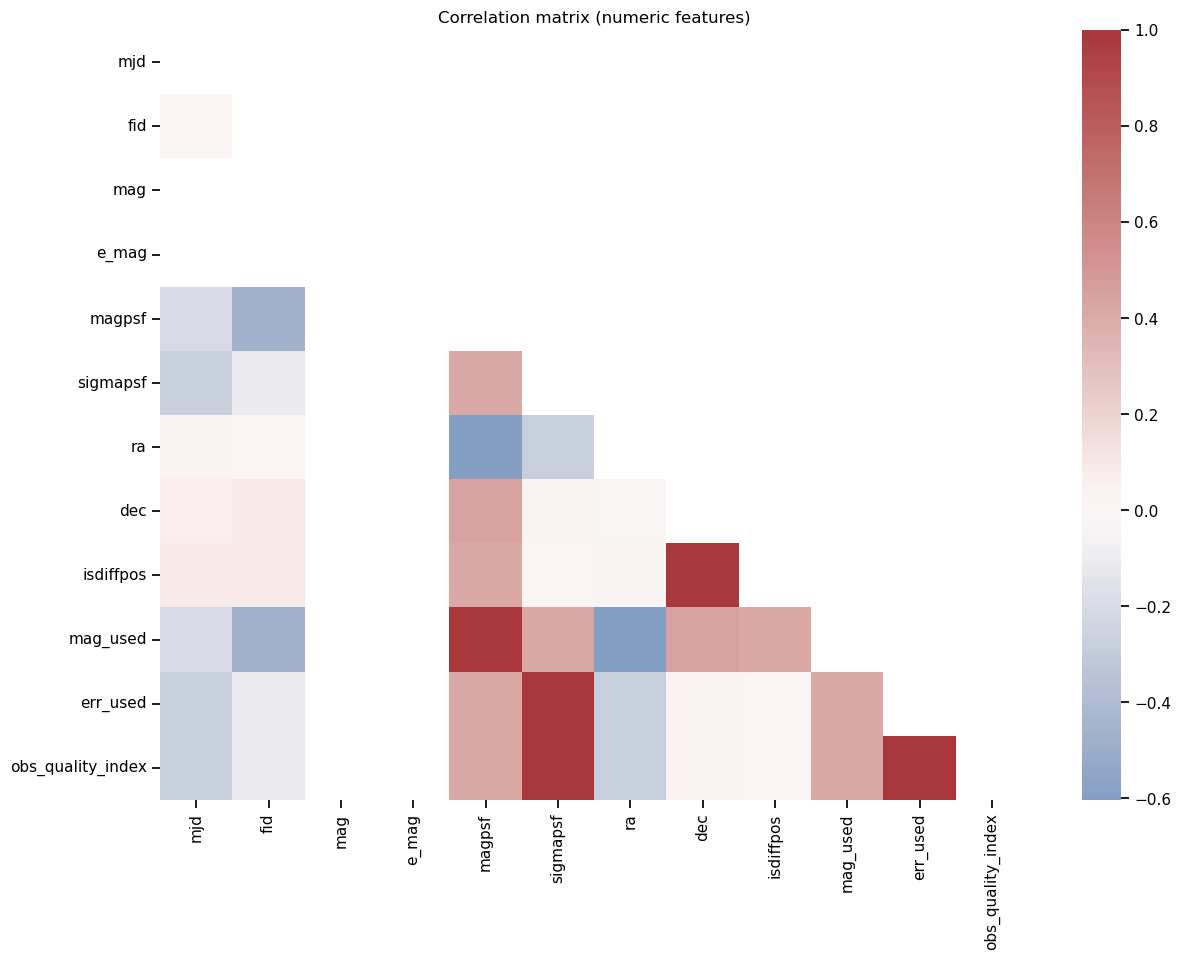

In [ ]:
# Bivariate: Correlation heatmap of numeric features
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(14,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='vlag', center=0, annot=False, fmt='.2f')
plt.title('Correlation matrix (numeric features)')
plt.show()

<details>
<summary>📌 Cell Description: Pairplot to Visualize Pairwise Relationships Between Numerical Features</summary>

This cell generates a **pairplot**, which is a grid of scatterplots showing how selected numerical features relate to one another. Each cell of the grid compares two variables, while the diagonal plots show the distribution of each feature individually. Because astronomical datasets often contain multiple measurements that may interact or show hidden patterns, a pairplot is a powerful visual tool for detecting relationships such as linear trends, clusters, or unusual point groupings.

To keep the plot readable, the cell selects only the first six numerical features and samples up to 5,000 rows. This prevents overcrowding and makes the visual patterns clearer. Pairplots give a rich, intuitive overview of how different features interact, making them a valuable step in exploratory data analysis before applying dimensionality reduction or machine-learning techniques.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Selects up to six numerical features** to avoid overwhelming the visualization with too many variables.  
- **Samples up to 5,000 rows**, ensuring the scatterplots remain clear and easy to interpret.  
- **Creates a grid of scatterplots**, showing how each pair of features relates to one another.  
- **Uses KDE curves on the diagonal**, providing smooth density estimates of individual feature distributions.  
- **Helps reveal patterns**, such as:  
  - linear relationships  
  - curved or non-linear relationships  
  - clusters or grouping of points  
  - outliers not caught earlier  
- **Provides early insight for modelling**, since correlated or structured variables may influence PCA, t-SNE, or clustering performance.  
- **Supports scientific interpretation**, because relationships between measurements can reveal instrument behavior or real astrophysical trends.

---

### ⭐ **Why This Cell Is Important for the Research**
Pairplots are one of the most informative tools for visualizing how multiple numerical features interact at once. In astronomy, features such as flux, flux error, signal-to-noise ratio, and positional coordinates often exhibit meaningful relationships. Understanding these relationships helps the researcher make better decisions about feature selection, dimensionality reduction, and model design. This cell ensures that any hidden trends or dependencies are discovered early, leading to more accurate scientific conclusions.

</details>


In [ ]:
# pick numeric columns
num_df = df.select_dtypes(include=[np.number]).copy()

# keep only columns that have at least 80% non-missing values
min_non_nan = int(0.8 * len(df))
good_cols = [c for c in num_df.columns if num_df[c].notna().sum() >= min_non_nan]

print("Good numeric cols:", good_cols)


Good numeric cols: ['mjd', 'fid', 'magpsf', 'sigmapsf', 'ra', 'dec', 'isdiffpos', 'mag_used', 'err_used', 'obs_quality_index']


<details>
<summary>📌 Cell Description: Sky Scatter Plot (RA vs Dec) to Visualize Spatial Distribution of Observations</summary>

This cell creates a **sky-map style scatter plot** using the astronomical coordinates Right Ascension (RA) and Declination (Dec). These two coordinates describe where an object lies on the celestial sphere, similar to longitude and latitude on Earth. Plotting RA vs. Dec allows the researcher to see the spatial coverage of the dataset—essentially showing **which parts of the sky** the ZTF observations come from.

The points are optionally colored by an additional numerical feature if one is available (such as *magnitude limit*, *seeing*, *airmass*, or *signal-to-noise ratio*). This adds a third dimension to the visualization and can reveal patterns such as how data quality or observing conditions vary across the sky. The plot uses sampling (up to 20,000 points) to remain clear and readable on large datasets. The RA axis is inverted to match standard astronomy conventions.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Checks for RA and Dec columns**, ensuring that spatial plotting is possible.  
- **Plots the sky distribution** of observations, showing how data points are spread across celestial coordinates.  
- **Applies optional color-coding** using a relevant numerical feature (e.g., *seeing*, *airmass*, *maglimit*, *snr*) to add scientific context.  
- **Uses sampling for efficiency**, preventing clutter when the dataset is very large.  
- **Adds a colorbar** when coloring is applied, helping interpret the meaning of the variation.  
- **Labels axes clearly** with RA and Dec in degrees, following astronomical standards.  
- **Inverts the RA axis**, which is the common convention in sky maps to match telescope sky projections.  
- **Helps visualize observational patterns**, such as:  
  - clusters of observations in certain sky regions  
  - observational gaps  
  - variations in data quality across the sky  
- **Supports further spatial analysis**, such as clustering or anomaly detection in celestial coordinates.

---

### ⭐ **Why This Cell Is Important for the Research**
Spatial visualization is essential in astronomy because observations are not uniformly


Rows after dropna: 20000


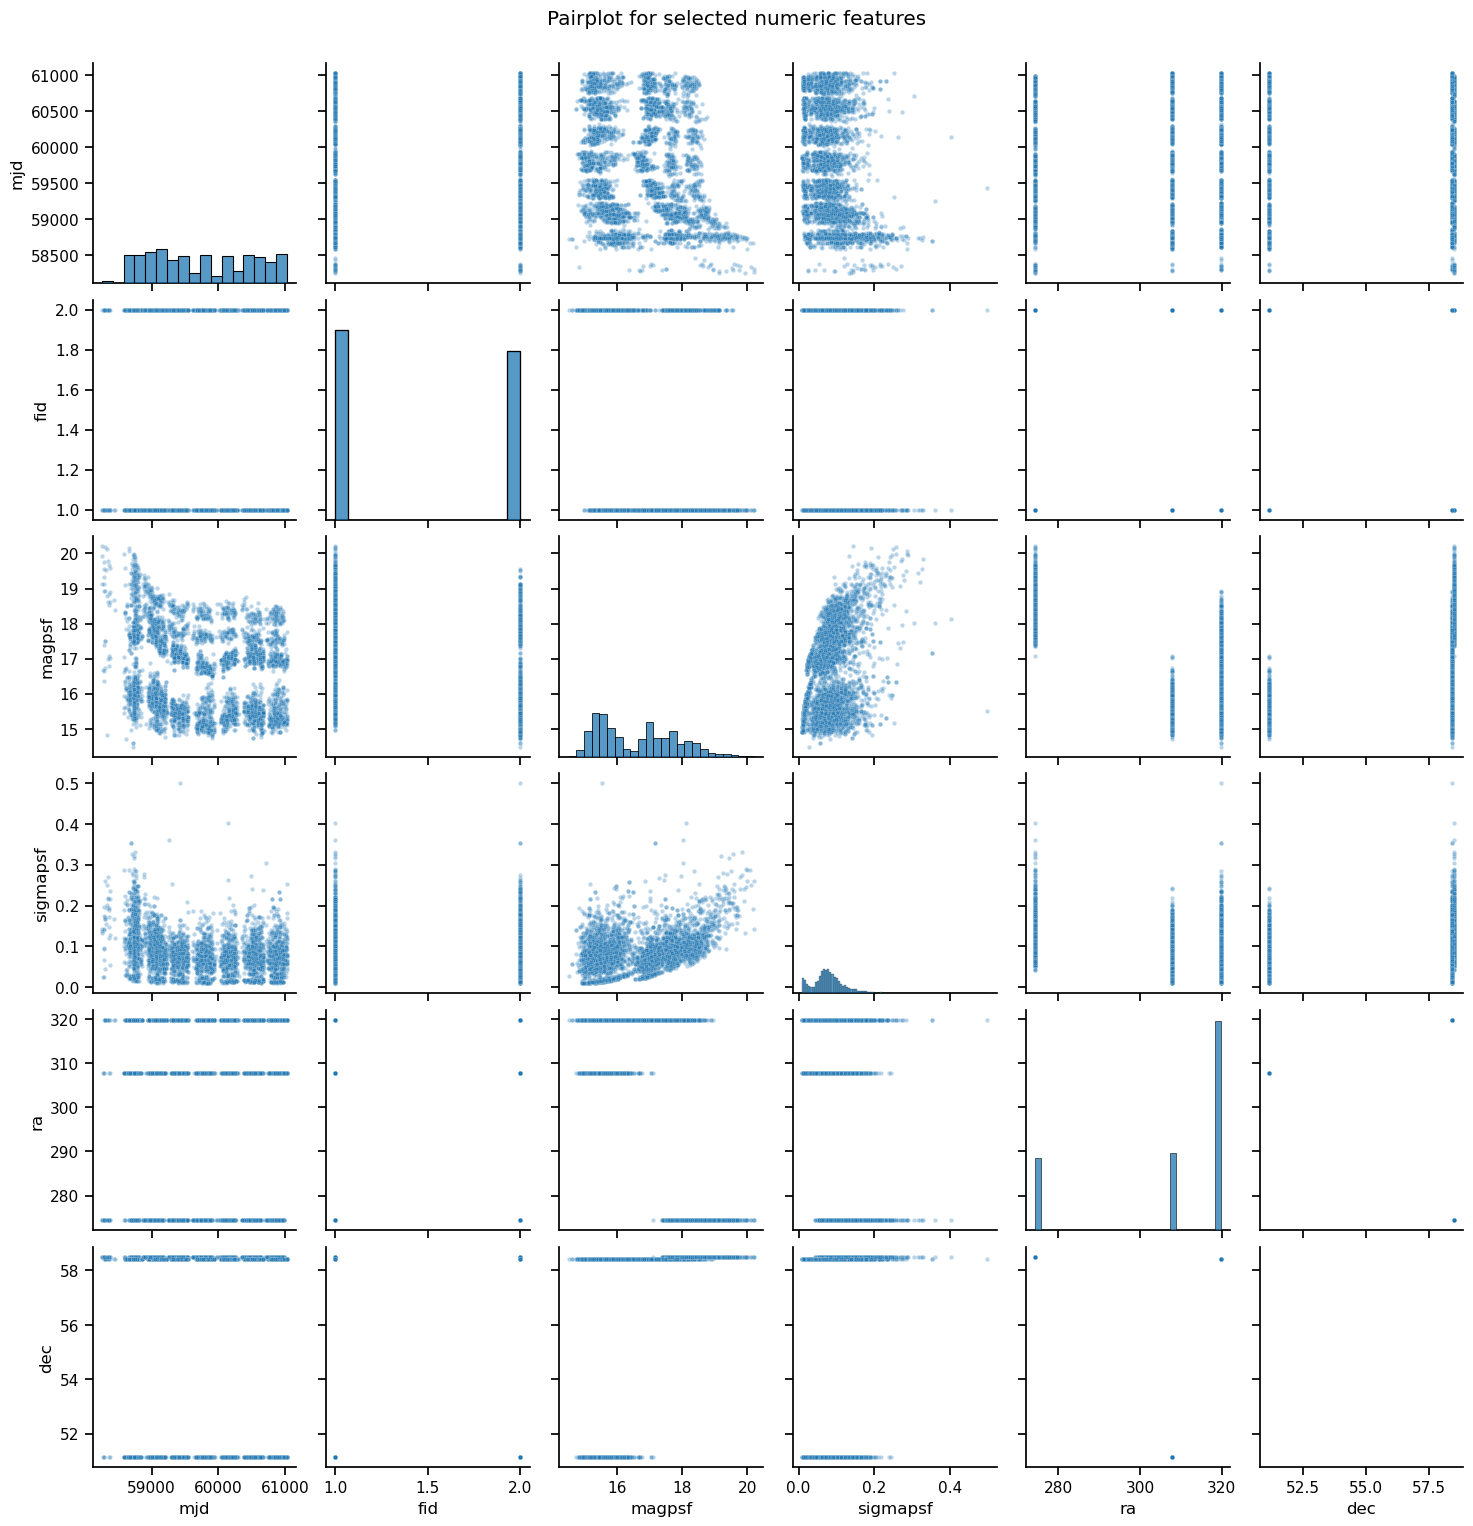

In [ ]:
pair_cols = good_cols[:6]  # take first 6 good numeric cols
pair_data = num_df[pair_cols].dropna()

print("Rows after dropna:", len(pair_data))

# sample after dropna
if len(pair_data) > 5000:
    pair_data = pair_data.sample(n=5000, random_state=42)

sns.pairplot(pair_data, diag_kind="hist", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairplot for selected numeric features", y=1.02)
plt.show()


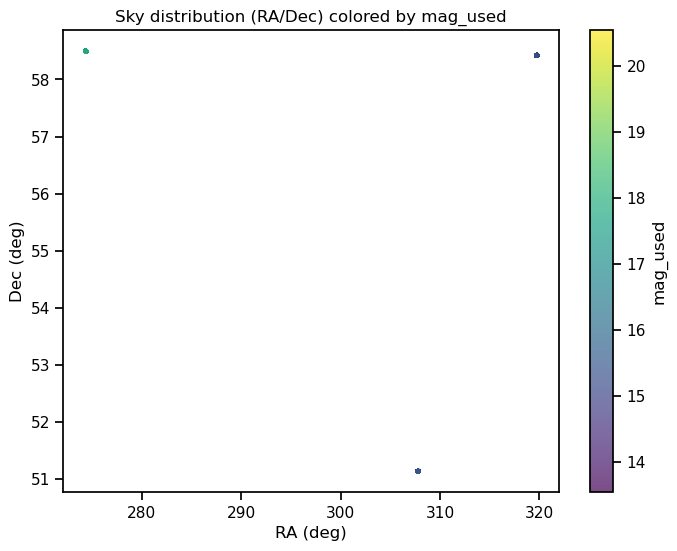

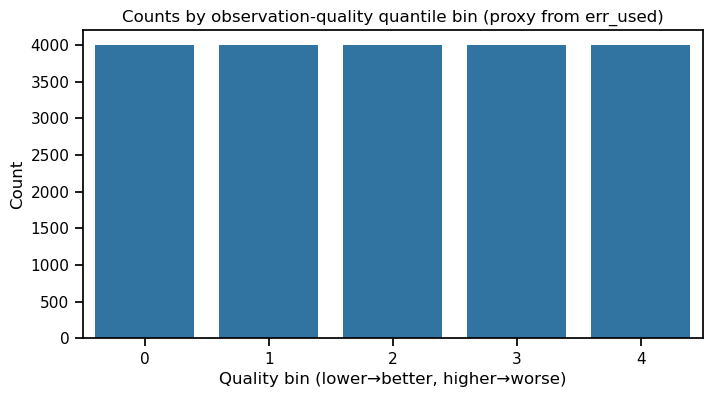

In [ ]:
# Spatial: sky scatter (RA, Dec) colored by an available feature
if set(['ra','dec']).issubset(df.columns):
    plt.figure(figsize=(8,6))

    # Choose a sensible color column from what's available
    color_candidates = ["mag_used", "err_used", "obs_quality_index"]
    color_col = next((c for c in color_candidates if c in df.columns and df[c].notna().any()), None)

    sample_sky = df.sample(n=20000, random_state=42) if df.shape[0] > 20000 else df

    if color_col:
        sc = plt.scatter(
            pd.to_numeric(sample_sky['ra'], errors="coerce"),
            pd.to_numeric(sample_sky['dec'], errors="coerce"),
            c=pd.to_numeric(sample_sky[color_col], errors="coerce"),
            s=6, cmap='viridis', alpha=0.7
        )
        plt.colorbar(sc, label=color_col)
        plt.title(f"Sky distribution (RA/Dec) colored by {color_col}")
    else:
        plt.scatter(
            pd.to_numeric(sample_sky['ra'], errors="coerce"),
            pd.to_numeric(sample_sky['dec'], errors="coerce"),
            s=6, alpha=0.7
        )
        plt.title("Sky distribution (RA/Dec)")

    plt.xlabel('RA (deg)')
    plt.ylabel('Dec (deg)')
    plt.show()

# Observation-quality bins (based on err_used if available)
if "obs_quality_index" in df.columns and df["obs_quality_index"].notna().any():
    tmp = df[["obs_quality_index"]].copy()
    tmp["obs_quality_index"] = pd.to_numeric(tmp["obs_quality_index"], errors="coerce")
    tmp = tmp.dropna()
    tmp["quality_bin"] = pd.qcut(tmp["obs_quality_index"], q=5, labels=False, duplicates="drop")

    plt.figure(figsize=(8,4))
    sns.countplot(x=tmp["quality_bin"])
    plt.title("Counts by observation-quality quantile bin (proxy from err_used)")
    plt.xlabel("Quality bin (lower→better, higher→worse)")
    plt.ylabel("Count")
    plt.show()


<details>
<summary>📌 Cell Description: Time-Series Plot Showing Number of Observations Per Date</summary>

This cell creates a **time-series plot** that shows how many astronomical observations were recorded on each day. Many ZTF datasets contain a date, time, or Julian Date (JD/MJD) column, and understanding how observations are distributed over time is important for identifying temporal patterns, observing schedules, seasonal variations, or gaps in data collection.

The cell automatically searches for any date-related column (e.g., containing "date", "time", "jd", "mjd", "obsdate"), converts it to a proper datetime format, counts the number of observations for each day, and then plots these counts as a line graph. This visual timeline helps the researcher see when the telescope was most active, whether certain periods had more observations, and if there are unusual gaps or bursts in data collection. If a valid date column cannot be parsed, the cell safely skips the plot without causing errors.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Automatically detects date-like columns** such as “date”, “time”, “JD”, “MJD”, or “obsdate”.  
- **Converts the detected column to datetime**, ensuring consistent handling of time information.  
- **Counts observations per day**, grouping the entire dataset into a daily timeline.  
- **Plots a time-series line graph**, showing how the number of observations changes over time.  
- **Visualizes activity patterns**, such as:  
  - nights with heavy observation  
  - days with few or no observations  
  - long gaps (bad weather, telescope downtime)  
  - seasonal or periodic trends  
- **Provides insight into observational cadence**, which is important in astronomy for time-dependent phenomena.  
- **Includes safe error handling**, ensuring the process skips gracefully if no date column is usable.  
- **Supports further temporal analysis**, such as studying time-based variability or scheduling patterns.

---

### ⭐ **Why This Cell Is Important for the Research**
Time is a fundamental dimension in astronomy. Observations are not evenly spaced—weather, telescope scheduling, and scientific priorities all influence when data is collected. Understanding the time distribution helps the researcher:

- evaluate whether the dataset suffers from **temporal bias**,  
- identify periods of dense or sparse observation,  
- ensure that machine-learning models do not misinterpret uneven time sampling,  
- prepare for future steps such as time-series modelling or variability studies.

This time-series plot transforms raw timestamps into a meaningful scientific overview, helping ensure that the dataset is well-understood before deeper analysis.

</details>


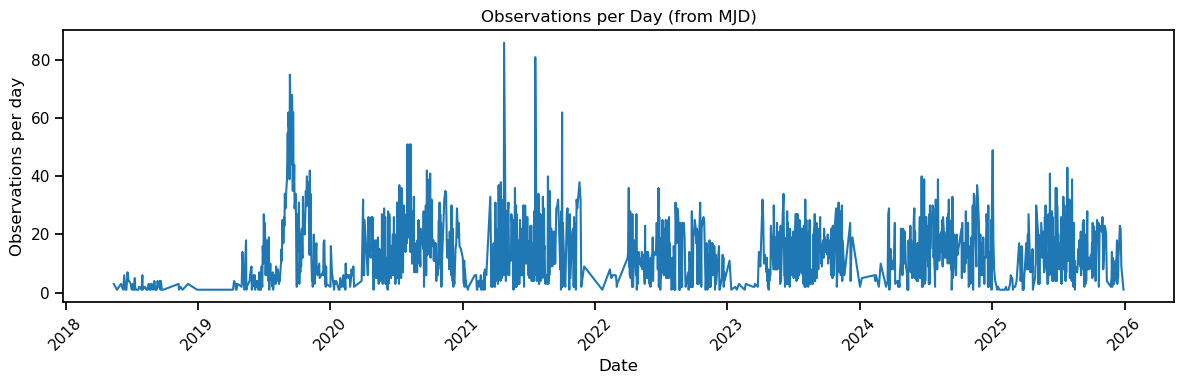

In [ ]:
from astropy.time import Time
import matplotlib.pyplot as plt

# Convert MJD to datetime correctly
t = Time(df['mjd'].values, format='mjd')
df['date'] = t.to_datetime()

# Count observations per day
counts = df['date'].dt.date.value_counts().sort_index()

plt.figure(figsize=(12,4))
plt.plot(counts.index, counts.values)
plt.xlabel("Date")
plt.ylabel("Observations per day")
plt.title("Observations per Day (from MJD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<details>
<summary>📌 Cell Description: PCA 2D Projection to Visualize High-Dimensional Astronomical Data</summary>

This cell applies **Principal Component Analysis (PCA)** to reduce the high-dimensional numerical dataset into a simple **2-dimensional (2D) projection**. PCA is a mathematical technique used to compress many features into just two new variables (PC1 and PC2) while preserving as much of the original information as possible. This is extremely useful in astronomy, where datasets often have dozens of numerical measurements per observation.

By projecting the dataset into 2D, the researcher can visually inspect overall structure: clusters, separations, gradients, and hidden patterns that are not obvious in the original high-dimensional space. The cell first selects all numerical columns, ensures they contain no missing data, optionally samples up to 20,000 rows for speed, performs PCA, and then plots the transformed values in a scatter plot. Each point represents an astronomical observation, now expressed in terms of the two most informative components.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Selects all clean numerical features**, ensuring PCA only uses valid data.  
- **Applies PCA with 2 components (PC1 and PC2)**, capturing the largest variance in the dataset.  
- **Samples up to 20,000 rows** to make plotting fast and readable.  
- **Transforms high-dimensional data into 2D**, making complex relationships visible.  
- **Plots a scatter diagram of PCA output**, where each point is one observation.  
- **PC1 and PC2 represent newly created features**, summarizing patterns in the original data.  
- **Highlights hidden structure**, such as:  
  - natural groupings or clusters  
  - smooth gradients  
  - outlier bands  
  - possible instrument or observational effects  
- **Acts as a starting point for advanced exploration**, like clustering, anomaly detection, or comparing different observation conditions.

---

### ⭐ **Why This Cell Is Important for the Research**
Astronomical datasets often contain many numerical measurements per observation (flux, flux error, SNR, coordinates, quality metrics, etc.). These features exist in a high-dimensional space that humans cannot visualize directly. PCA converts this complex data into a 2D representation without losing the core structure.

This visualization helps the researcher:

- understand overall dataset structure  
- detect hidden scientific patterns  
- assess whether preprocessing steps improved data quality  
- identify clusters that may represent different object types or observation conditions  
- spot unusual or anomalous points for further investigation  

PCA is therefore a powerful tool that bridges raw data and high-level scientific insight, making it an essential component of exploratory astroinformatics.

</details>


In [ ]:
# Identify continuous numeric columns
cont_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Remove identifier columns if present
for col in ["oid", "fid", "isdiff"]:
    if col in cont_cols:
        cont_cols.remove(col)


NameError: name 'df' is not defined

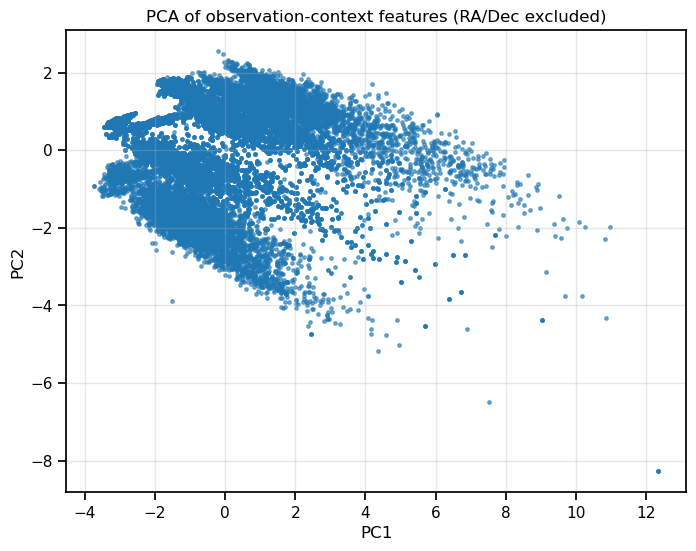

Used columns: ['mjd', 'magpsf', 'sigmapsf', 'isdiffpos', 'mag_used', 'err_used', 'obs_quality_index']
Explained variance ratio: [0.54129815 0.2423808 ]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

exclude_spatial = True
embed_cont_cols = [c for c in cont_cols if (not exclude_spatial) or (c not in ["ra", "dec"])]

# 1) Take only chosen columns
X = df[embed_cont_cols].copy()

# 2) Force numeric safely (anything non-numeric becomes NaN)
for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# 3) Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 4) Drop columns that are entirely NaN (median would be NaN)
X = X.dropna(axis=1, how="all")

# 5) Now fill remaining NaNs with median (works because not all-NaN columns remain)
X = X.fillna(X.median(numeric_only=True))

# 6) Safety: if any NaNs still exist, drop those rows
X = X.dropna(axis=0)

if X.shape[1] >= 2 and len(X) > 10:
    Xs = X.sample(n=min(30000, len(X)), random_state=42)

    scaler = StandardScaler()
    Xs_scaled = scaler.fit_transform(Xs.values)

    pca = PCA(n_components=2, random_state=42)
    Xp = pca.fit_transform(Xs_scaled)

    plt.figure(figsize=(8, 6))
    plt.scatter(Xp[:, 0], Xp[:, 1], s=6, alpha=0.6)
    plt.title("PCA of observation-context features" + (" (RA/Dec excluded)" if exclude_spatial else ""))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.3)
    plt.show()

    print("Used columns:", list(X.columns))
    print("Explained variance ratio:", pca.explained_variance_ratio_)
else:
    print("Not enough usable numeric features after cleaning for PCA.")
    print("Remaining columns:", list(X.columns))
    print("Remaining rows:", len(X))


<details>
<summary>📌 Cell Description: Visualizing High-Dimensional Data Using t-SNE or UMAP Embeddings</summary>

This cell creates a **2D embedding** of the high-dimensional astronomical dataset using either **UMAP** (if available) or **t-SNE**. Both methods are advanced dimensionality-reduction techniques specifically designed to reveal complex structures that PCA sometimes cannot capture. They are especially useful when the dataset has non-linear relationships, clusters, or subtle patterns that exist in high-dimensional space.

The cell selects all numerical features, removes columns with missing values, and samples up to 2,000 rows to keep computation fast and reliable. It then applies either UMAP (preferred because it preserves global and local structure well) or t-SNE (a widely used method for visualizing clusters). The resulting 2D embedding is plotted as a scatter plot, where each point represents an astronomical observation in a compressed, visually interpretable form.

This visualization can reveal meaningful groupings, anomalies, transitions, or instrument effects that are not visible in raw data.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Selects clean numerical features**, ensuring embeddings are built on consistent data.  
- **Uses a sample of up to 2,000 rows** to balance speed and clarity.  
- **Automatically chooses UMAP if installed**, otherwise falls back to t-SNE.  
- **Both methods reduce complex multi-dimensional data to 2D**, allowing intuitive visualization.  
- **Creates a scatter plot where each point is an observation**, showing how data naturally clusters.  
- **Highlights non-linear structures**, such as:  
  - groups or clusters of observations  
  - smooth transitions representing physical processes  
  - isolated outliers that may indicate anomalies  
  - instrument- or filter-dependent patterns  
- **Gives insight into the underlying scientific structure** of the dataset beyond what PCA can show.  
- **Names the plot accordingly**, making it clear which method is used.

---

### ⭐ **Why This Cell Is Important for the Research**
Astronomical datasets are often high-dimensional and noisy. Tradit


C:\Users\NIPUN\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


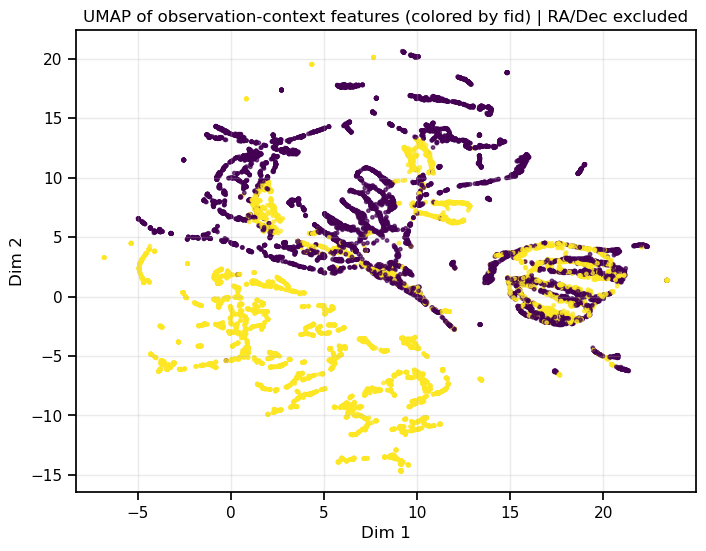

Used columns: ['mjd', 'magpsf', 'sigmapsf', 'isdiffpos', 'mag_used', 'err_used', 'obs_quality_index']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

exclude_spatial = True
embed_cont_cols = [c for c in cont_cols if (not exclude_spatial) or (c not in ["ra", "dec"])]

if len(embed_cont_cols) >= 2:
    # --- Build X safely (numeric coercion + cleaning) ---
    X = df[embed_cont_cols].copy()

    # Force numeric; non-numeric -> NaN
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    # Replace inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # Drop columns that are completely NaN
    X = X.dropna(axis=1, how="all")

    # Fill remaining NaNs with median
    X = X.fillna(X.median(numeric_only=True))

    # Final safety: drop any rows still having NaN
    X = X.dropna(axis=0)

    if X.shape[1] < 2 or len(X) < 50:
        print("Not enough usable numeric data after cleaning for projection.")
        print("Remaining columns:", list(X.columns))
        print("Remaining rows:", len(X))
    else:
        # sample for speed
        Xs = X.sample(n=min(15000, len(X)), random_state=42)

        scaler = StandardScaler()
        Xs_scaled = scaler.fit_transform(Xs.values)

        # choose reducer
        if "HAS_UMAP" in globals() and HAS_UMAP:
            reducer = umap.UMAP(n_components=2, random_state=42)
            X2 = reducer.fit_transform(Xs_scaled)
            method = "UMAP"
        else:
            reducer = TSNE(
                n_components=2,
                random_state=42,
                perplexity=30,
                init="pca",
                learning_rate="auto"
            )
            X2 = reducer.fit_transform(Xs_scaled)
            method = "t-SNE"

        # Color by fid (aligned index)
        plt.figure(figsize=(8, 6))
        if "fid" in df.columns:
            cvals = df.loc[Xs.index, "fid"].astype("category").cat.codes
            plt.scatter(X2[:, 0], X2[:, 1], s=6, alpha=0.7, c=cvals)
            plt.title(f"{method} of observation-context features (colored by fid)"
                      + (" | RA/Dec excluded" if exclude_spatial else ""))
        else:
            plt.scatter(X2[:, 0], X2[:, 1], s=6, alpha=0.7)
            plt.title(f"{method} of observation-context features"
                      + (" | RA/Dec excluded" if exclude_spatial else ""))

        plt.xlabel("Dim 1")
        plt.ylabel("Dim 2")
        plt.grid(alpha=0.25)
        plt.show()

        print("Used columns:", list(X.columns))
else:
    print("Not enough continuous features for embedding projection (need >=2).")


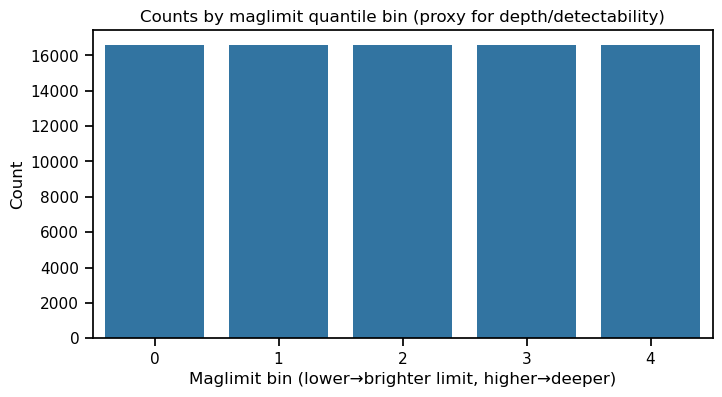

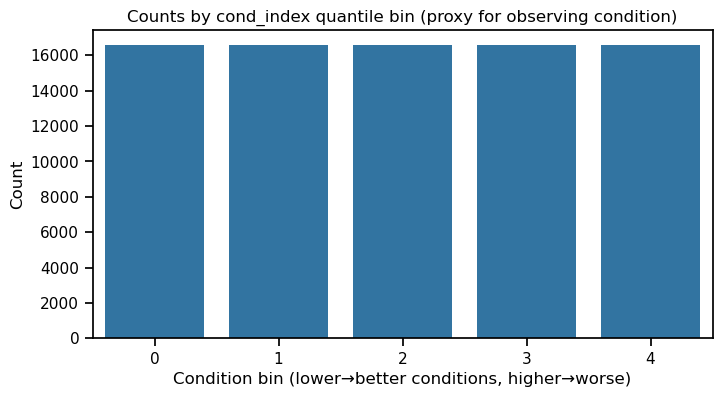

In [ ]:
# Observation quality / detectability proxies (bins) for the new dataset
# These plots are designed to work even when extra metadata (maglimit/seeing/airmass) is not present.

# 1) Magnitude distribution bins (using mag_used)
if "mag_used" in df.columns and df["mag_used"].notna().any():
    tmp = df[["mag_used"]].copy()
    tmp["mag_used"] = pd.to_numeric(tmp["mag_used"], errors="coerce")
    tmp = tmp.dropna()
    tmp["mag_bin"] = pd.qcut(tmp["mag_used"], q=5, labels=False, duplicates="drop")

    plt.figure(figsize=(8,4))
    sns.countplot(x=tmp["mag_bin"])
    plt.title("Counts by magnitude quantile bin (mag_used)")
    plt.xlabel("Magnitude bin (lower→brighter, higher→fainter)")
    plt.ylabel("Count")
    plt.show()

# 2) Photometric uncertainty bins (using err_used)
if "err_used" in df.columns and df["err_used"].notna().any():
    tmp = df[["err_used"]].copy()
    tmp["err_used"] = pd.to_numeric(tmp["err_used"], errors="coerce")
    tmp = tmp.dropna()
    tmp["err_bin"] = pd.qcut(tmp["err_used"], q=5, labels=False, duplicates="drop")

    plt.figure(figsize=(8,4))
    sns.countplot(x=tmp["err_bin"])
    plt.title("Counts by photometric-uncertainty quantile bin (err_used)")
    plt.xlabel("Uncertainty bin (lower→cleaner, higher→noisier)")
    plt.ylabel("Count")
    plt.show()

# 3) Multi-band balance (fid / filter_name)
if "filter_name" in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df["filter_name"])
    plt.title("Observation counts by filter (multi-band balance)")
    plt.xlabel("Filter")
    plt.ylabel("Count")
    plt.show()


<details>
<summary>📌 Cell Description: Missingness Heatmap to Visualize Patterns of Missing Data</summary>

This cell generates a **heatmap that shows where missing values occur** in the dataset. Even after earlier cleaning steps, it is important to visually confirm that no unexpected gaps remain. The heatmap displays each column as a vertical bar and each row as a horizontal point. Missing values appear as colored marks, and present values appear differently, allowing the researcher to instantly see whether missingness is random or concentrated in specific parts of the dataset.

Visualizing missing data in this way helps ensure the dataset is complete before dimensionality reduction, modeling, or statistical analysis. It also acts as a final validation step to check whether earlier preprocessing—such as replacing placeholders, imputing values, or removing defective rows—was successful.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Creates a heatmap of missing values**, giving a visual overview of data completeness.  
- **Each row represents an observation**, and each column represents a feature.  
- **Missing cells are highlighted**, showing exactly where data gaps exist.  
- **Confirms whether preprocessing removed missing entries correctly**, or if additional cleaning is needed.  
- **Helps detect patterns**, such as:  
  - missingness concentrated in certain features  
  - entire blocks of missing rows  
  - random scattered missing points  
- **Uses Seaborn’s clean heatmap design**, making patterns easy to interpret.  
- **Acts as a final quality check** before applying machine learning or visualization methods that require fully complete data.

---

### ⭐ **Why This Cell Is Important for the Research**
Before building machine-learning models or performing scientific analysis, it is vital to understand whether the dataset still contains missing values. Some algorithms completely fail with missing data, while others produce misleading results. 

This heatmap ensures:

- the dataset is truly complete,  
- missingness does not follow a hidden pattern that could bias results,  
- previous cleaning steps worked as intended,  
- the data is ready for advanced modeling.

By visually confirming the absence (or presence) of missing values, this cell enhances the reliability and scientific rigor of the entire research pipeline.

</details>


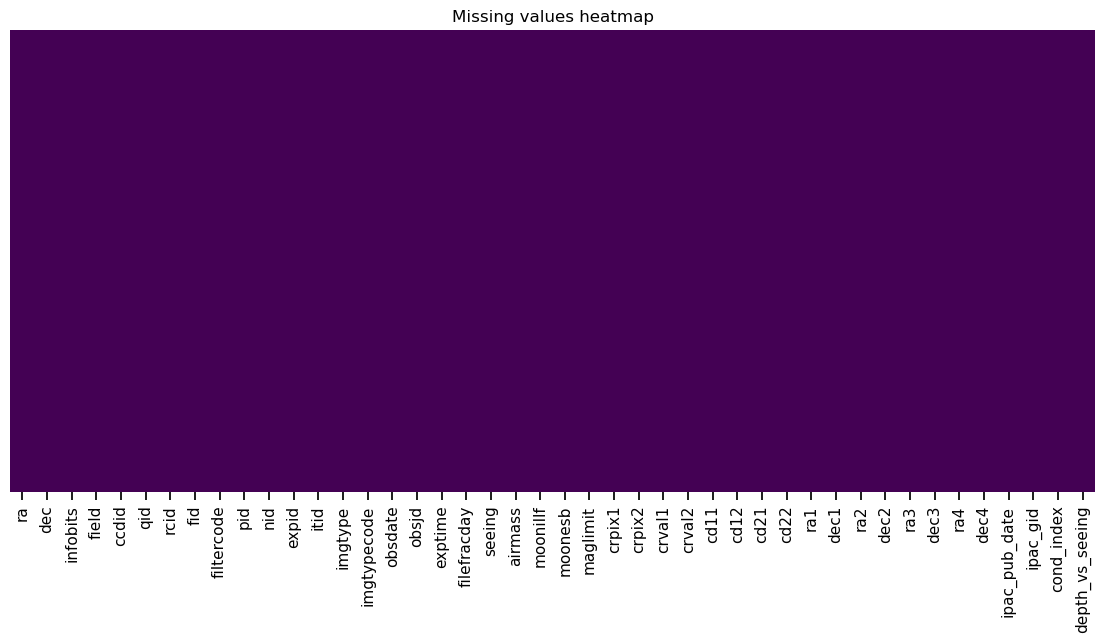

In [ ]:
# Missingness heatmap
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing values heatmap')
plt.show()


<details>
<summary>📌 Cell Description: Saving Figures and Creating an Organized Output Folder</summary>

This cell creates a dedicated **figures/** directory and saves selected visualizations—such as the correlation heatmap—into that folder. Saving figures is an important step in any research workflow because it preserves the visual outputs generated during analysis. These saved images can later be included in the research report, presentation slides, appendix material, or shared with supervisors and collaborators. The cell ensures the folder exists (creating it if needed), generates a correlation heatmap again, and exports it as a high-quality PNG file.

This approach keeps the project organized, makes the results reproducible, and ensures that every important visualization generated during exploratory analysis can be stored, referenced, and reused.

---

### 🔹 **Key Points (Simple & Attractive Explanation)**

- **Creates a dedicated `figures/` folder**, ensuring all plots are stored neatly in one place.  
- **Uses `os.makedirs(..., exist_ok=True)`**, which creates the directory only if it does not already exist.  
- **Recomputes and saves the correlation heatmap**, one of the core exploratory visualizations.  
- **Exports the figure as a PNG file** with good resolution (`dpi=150`).  
- **Keeps figures separate from code**, improving project structure and reproducibility.  
- **Helps with report writing**, since saved figures can be inserted directly into the thesis or appendix.  
- **Allows collaborators or evaluators to view results** without needing to re-run all code.  
- **Ensures consistent file naming**, making it easy to track outputs across the research pipeline.

---

### ⭐ **Why This Cell Is Important for the Research**
Saving visual outputs is a crucial part of any scientific workflow. Figures are often required for:

- research papers  
- presentations  
- viva examinations  
- documentation and appendix sections  
- comparative experiments or audits  

By automatically generating and saving figures, this cell ensures that key insights from the data—such as correlations between astronomical features—are preserved permanently. This improves transparency, reproducibility, and the overall professionalism of the research project.

</details>


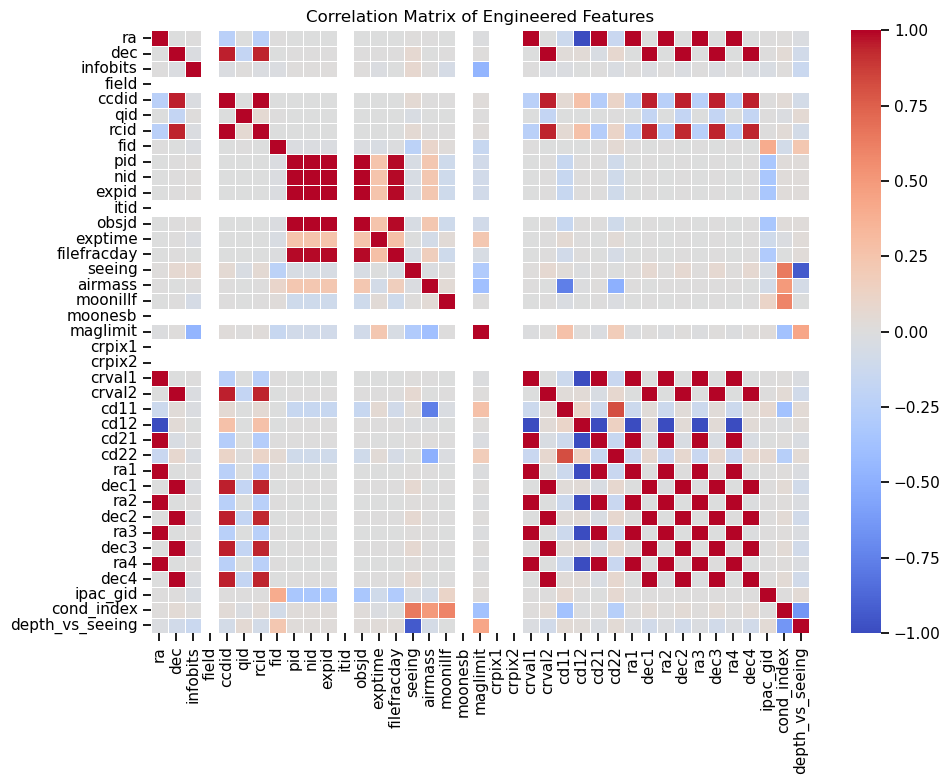

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.4,
    linecolor='white'
)
plt.title('Correlation Matrix of Engineered Features')
plt.tight_layout()
plt.show()
plt.close()


## Additional Visualizations (Requested)
These cells add the univariate, bivariate, multivariate, time-series, class-based and data-quality plots you requested. Each cell checks for required columns and skips gracefully if data is missing.

In [ ]:
# 1) Univariate: Histograms + KDE, Box + Violin (selected columns)
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
cols_map = {'magpsf':'mag_used', 'sigmapsf':'err_used', 'mjd':'mjd', 'ra':'ra', 'dec':'dec', 'seeing':'seeing', 'airmass':'airmass', 'maglimit':'maglimit'}
present = [v for k,v in cols_map.items() if v in df.columns or k in df.columns]
# ensure we reference actual column names (prefer standardized names like mag_used/err_used)
uni_cols = []
for k,v in cols_map.items():
    if v in df.columns:
        uni_cols.append(v)
    elif k in df.columns:
        uni_cols.append(k)
# dedupe
uni_cols = list(dict.fromkeys(uni_cols))
if uni_cols:
    n = len(uni_cols)
    ncols = 3
    nrows = ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols,3*nrows))
    axes = axes.flatten() if n>1 else [axes]
    for i, c in enumerate(uni_cols):
        data = pd.to_numeric(df[c], errors='coerce').dropna()
        if data.empty:
            axes[i].text(0.5,0.5,f'No data for {c}',ha='center')
            axes[i].set_title(c)
            continue
        sns.histplot(data, kde=True, ax=axes[i], bins=60, color='C0')
        axes[i].set_title(c)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print('No univariate columns found for the requested list.')

# Box + Violin for magnitude / error grouped by filter (if available)
if 'mag_used' in df.columns and 'filter_name' in df.columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(x='filter_name', y='mag_used', data=df, palette='Set2')
    plt.title('mag_used by filter (boxplot)')
    plt.gca().invert_yaxis()
    plt.show()
    plt.figure(figsize=(10,4))
    sns.violinplot(x='filter_name', y='mag_used', data=df, palette='Set2')
    plt.title('mag_used by filter (violin)')
    plt.gca().invert_yaxis()
    plt.show()

if 'err_used' in df.columns and 'filter_name' in df.columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(x='filter_name', y='err_used', data=df, palette='Set3')
    plt.title('err_used by filter (boxplot)')
    plt.show()

In [ ]:
# 2) Bivariate: Scatter/Hexbin/Line (light-curve examples)
# Scatter: mjd vs mag_used (raw light curve scatter)
if 'mjd' in df.columns and ('mag_used' in df.columns or 'magpsf' in df.columns):
    ycol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    samp = df.sample(n=min(20000, len(df)), random_state=42) if len(df)>20000 else df
    plt.figure(figsize=(8,4))
    plt.scatter(pd.to_numeric(samp['mjd'],errors='coerce'), pd.to_numeric(samp[ycol],errors='coerce'), s=6, alpha=0.6)
    plt.gca().invert_yaxis()
    plt.xlabel('mjd')
    plt.ylabel(ycol)
    plt.title('Scatter: mjd vs ' + ycol)
    plt.show()
else:
    print('Skipping mjd vs magnitude scatter (columns missing)')

# Hexbin for dense mjd vs mag
if 'mjd' in df.columns and ('mag_used' in df.columns or 'magpsf' in df.columns):
    ycol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    x = pd.to_numeric(df['mjd'],errors='coerce')
    y = pd.to_numeric(df[ycol],errors='coerce')
    mask = x.notna() & y.notna()
    if mask.sum()>0:
        plt.figure(figsize=(8,4))
        plt.hexbin(x[mask], y[mask], gridsize=80, cmap='inferno')
        plt.gca().invert_yaxis()
        plt.colorbar(label='counts')
        plt.xlabel('mjd')
        plt.ylabel(ycol)
        plt.title('Hexbin: mjd vs ' + ycol)
        plt.show()

# Line: single-object light curve (choose oid with most obs)
if 'oid' in df.columns and 'mjd' in df.columns and ('mag_used' in df.columns or 'magpsf' in df.columns):
    ycol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    top_oid = df['oid'].value_counts().index[0]
    df_oid = df[df['oid']==top_oid].copy()
    df_oid['mjd'] = pd.to_numeric(df_oid['mjd'],errors='coerce')
    df_oid = df_oid.sort_values('mjd')
    plt.figure(figsize=(10,4))
    if 'filter_name' in df_oid.columns:
        for f, g in df_oid.groupby('filter_name'):
            plt.plot(g['mjd'], pd.to_numeric(g[ycol],errors='coerce'), marker='o', linestyle='-', alpha=0.7, label=f)
        plt.legend(title='filter')
    else:
        plt.plot(df_oid['mjd'], pd.to_numeric(df_oid[ycol],errors='coerce'), marker='o', linestyle='-')
    plt.gca().invert_yaxis()
    plt.xlabel('mjd')
    plt.ylabel(ycol)
    plt.title(f'Example light curve for oid={top_oid}')
    plt.show()
else:
    print('Skipping single-object light curve (missing oid/mjd/mag)')

# Bivariate numeric vs numeric examples: mag vs err, airmass vs mag
if ('mag_used' in df.columns or 'magpsf' in df.columns) and ('err_used' in df.columns or 'sigmapsf' in df.columns):
    mcol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    ecol = 'err_used' if 'err_used' in df.columns else ('sigmapsf' if 'sigmapsf' in df.columns else None)
    if ecol is not None:
        plt.figure(figsize=(6,4))
        plt.scatter(pd.to_numeric(df[mcol],errors='coerce'), pd.to_numeric(df[ecol],errors='coerce'), s=6, alpha=0.4)
        plt.xlabel(mcol)
        plt.ylabel(ecol)
        plt.title(mcol + ' vs ' + ecol)
        plt.show()

if 'airmass' in df.columns and ('mag_used' in df.columns or 'magpsf' in df.columns):
    mcol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    plt.figure(figsize=(6,4))
    plt.scatter(pd.to_numeric(df['airmass'],errors='coerce'), pd.to_numeric(df[mcol],errors='coerce'), s=6, alpha=0.4)
    plt.xlabel('airmass')
    plt.ylabel(mcol)
    plt.title('airmass vs ' + mcol)
    plt.gca().invert_yaxis()
    plt.show()

# mag vs maglimit (if present)
if ('mag_used' in df.columns or 'magpsf' in df.columns) and 'maglimit' in df.columns:
    mcol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    plt.figure(figsize=(6,4))
    plt.hexbin(pd.to_numeric(df[mcol],errors='coerce'), pd.to_numeric(df['maglimit'],errors='coerce'), gridsize=70, cmap='plasma')
    plt.xlabel(mcol)
    plt.ylabel('maglimit')
    plt.title(mcol + ' vs maglimit')
    plt.colorbar(label='counts')
    plt.show()

In [ ]:
# 3) Categorical vs Numeric & Categorical vs Categorical
# mag grouped by fid / filter_name
if ('mag_used' in df.columns or 'magpsf' in df.columns) and 'filter_name' in df.columns:
    ycol = 'mag_used' if 'mag_used' in df.columns else 'magpsf'
    plt.figure(figsize=(8,4))
    sns.boxplot(x='filter_name', y=ycol, data=df, palette='Pastel1')
    plt.title(f'{ycol} by filter (boxplot)')
    plt.gca().invert_yaxis() if ycol.lower().startswith('mag') else None
    plt.show()

# Count plots: fid / class distribution
if 'filter_name' in df.columns:
    plt.figure(figsize=(6,3))
    sns.countplot(x=df['filter_name'], palette='viridis')
    plt.title('Counts by filter')
    plt.show()

class_cols = [c for c in df.columns if c.lower() in ['class','label','target']]
if class_cols:
    cls = class_cols[0]
    plt.figure(figsize=(6,3))
    sns.countplot(y=cls, data=df, order=df[cls].value_counts().index[:20])
    plt.title('Class distribution (top 20)')
    plt.show()
else:
    print('No obvious class/label column found for class-based plots')

In [ ]:
# 4) Multivariate: Pairplot + Parallel Coordinates
pair_cols = [c for c in ['mag_used','err_used','mjd','airmass'] if c in df.columns]
if len(pair_cols) >= 2:
    sample = df[pair_cols].dropna().sample(n=min(3000, len(df)), random_state=42) if len(df) > 3000 else df[pair_cols].dropna()
    try:
        sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha':0.4, 's':20})
        plt.suptitle('Pairplot for selected features', y=1.02)
        plt.show()
    except Exception as e:
        print('Pairplot failed:', e)
else:
    print('Not enough columns for pairplot')

# Parallel coordinates for a few objects (select top 5 oids)
from pandas.plotting import parallel_coordinates
if 'oid' in df.columns:
    top_oids = df['oid'].value_counts().nlargest(5).index.tolist()
    pc_df = df[df['oid'].isin(top_oids)].copy()
    feat_cols = [c for c in ['mag_used','err_used','mjd','airmass'] if c in pc_df.columns]
    if feat_cols:
        pc_plot = pc_df[['oid'] + feat_cols].dropna()
        pc_plot['oid'] = pc_plot['oid'].astype(str)
        plt.figure(figsize=(10,4))
        parallel_coordinates(pc_plot.rename(columns={'oid':'class'}) , 'class', color=['C0','C1','C2','C3','C4'])
        plt.title('Parallel coordinates (top 5 oids)')
        plt.show()
    else:
        print('Not enough numeric features for parallel coordinates')
else:
    print('No oid column; skipping parallel coordinates')

In [ ]:
# 5) Data-quality: observation counts per object and missingness summary
if 'oid' in df.columns:
    counts = df['oid'].value_counts()
    plt.figure(figsize=(8,4))
    sns.histplot(counts, bins=50, color='C2')
    plt.title('Distribution of observation counts per oid')
    plt.xlabel('observations per oid')
    plt.show()
    plt.figure(figsize=(8,4))
    sns.barplot(x=counts.nlargest(10).values, y=counts.nlargest(10).index.astype(str), palette='magma')
    plt.title('Top 10 oids by observation count')
    plt.xlabel('count')
    plt.show()
else:
    print('No oid column for observation-count plots')

# Missingness heatmap (percentage per column)
miss = df.isnull().mean().sort_values(ascending=False)*100
plt.figure(figsize=(8,4))
sns.barplot(x=miss.values, y=miss.index, palette='rocket')
plt.xlabel('Percent missing')
plt.title('Missingness per column (%)')
plt.show()